In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [57]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_cleaned.csv')
#df = df.drop(['index'], axis=1)

df.head()

,index,fire_size,fire_size_class,latitude,longitude,discovery_month,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,...,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
0,0,10.0,C,18.105072,-66.753044,Feb,12,24.480974,24.716923,24.902597,...,3.492857,3.262092,78.216590,76.793750,76.381579,0.0,0.0,0.0,0.017923,1
1,1,3.0,B,35.038330,-87.610000,Dec,15,7.553433,7.010000,0.343529,...,2.881707,1.976471,70.840000,65.858911,55.505882,59.8,8.4,0.0,0.184355,0
2,2,60.0,C,34.947800,-88.722500,Feb,16,4.971930,5.782766,5.558750,...,2.923830,2.695833,75.531629,75.868613,76.812834,168.8,42.2,18.1,0.194544,1
3,3,1.0,B,39.641400,-119.308300,Jun,0,16.275967,18.996181,18.142564,...,3.398329,3.671282,44.778429,37.140811,35.353846,10.4,7.2,0.0,0.487447,0
4,4,5.2,B,31.316978,-83.393649,Jan,12,14.877341,16.409326,17.175319,...,1.727202,1.590696,79.896679,73.431818,70.199388,26.0,0.0,0.0,0.148904,0


In [58]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37208 entries, 0 to 37207
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            37208 non-null  int64  
 1   fire_size        37208 non-null  float64
 2   fire_size_class  37208 non-null  object 
 3   latitude         37208 non-null  float64
 4   longitude        37208 non-null  float64
 5   discovery_month  37208 non-null  object 
 6   Vegetation       37208 non-null  int64  
 7   Temp_pre_30      37208 non-null  float64
 8   Temp_pre_15      37208 non-null  float64
 9   Temp_pre_7       37208 non-null  float64
 10  Wind_pre_30      37208 non-null  float64
 11  Wind_pre_15      37208 non-null  float64
 12  Wind_pre_7       37208 non-null  float64
 13  Hum_pre_30       37208 non-null  float64
 14  Hum_pre_15       37208 non-null  float64
 15  Hum_pre_7        37208 non-null  float64
 16  Prec_pre_30      37208 non-null  float64
 17  Prec_pre_15 

,index,fire_size,latitude,longitude,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
count,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000
mean,20491.940443,2211.284929,36.475461,-95.643236,11.072646,15.751560,16.252676,16.611517,3.171764,3.160079,3.136735,60.973810,60.040488,58.948962,39.482359,17.723995,7.361304,0.243298,0.346216
std,11841.298864,14890.174705,6.813169,15.877186,5.556529,8.534825,8.417871,8.474401,1.177843,1.227829,1.313413,13.714828,14.182339,14.894387,134.725873,68.620599,37.778079,0.144646,0.475769
min,0.000000,0.510000,17.958364,-165.116700,0.000000,-16.078723,-37.000000,-48.200000,0.024922,0.017250,0.000000,5.625000,5.625000,5.625000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10251.750000,1.100000,32.377439,-103.445108,9.000000,9.127583,9.715080,10.037742,2.350902,2.299691,2.221819,55.237437,53.461904,50.968015,0.000000,0.000000,0.000000,0.140661,0.000000
50%,20458.500000,4.000000,34.699420,-93.185815,12.000000,15.555082,16.070776,16.600000,3.072371,3.053857,3.010513,64.213802,63.044628,61.650099,3.400000,0.000000,0.000000,0.210863,0.000000
75%,30726.250000,20.000000,39.783547,-83.550410,15.000000,23.115392,23.434649,23.793842,3.868383,3.877827,3.891667,70.334410,69.892706,69.469600,43.600000,15.125000,2.300000,0.291913,1.000000
max,41131.000000,538049.000000,69.047200,-65.417709,16.000000,41.677820,51.567797,55.000000,29.800000,29.800000,29.800000,96.000000,96.000000,100.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000


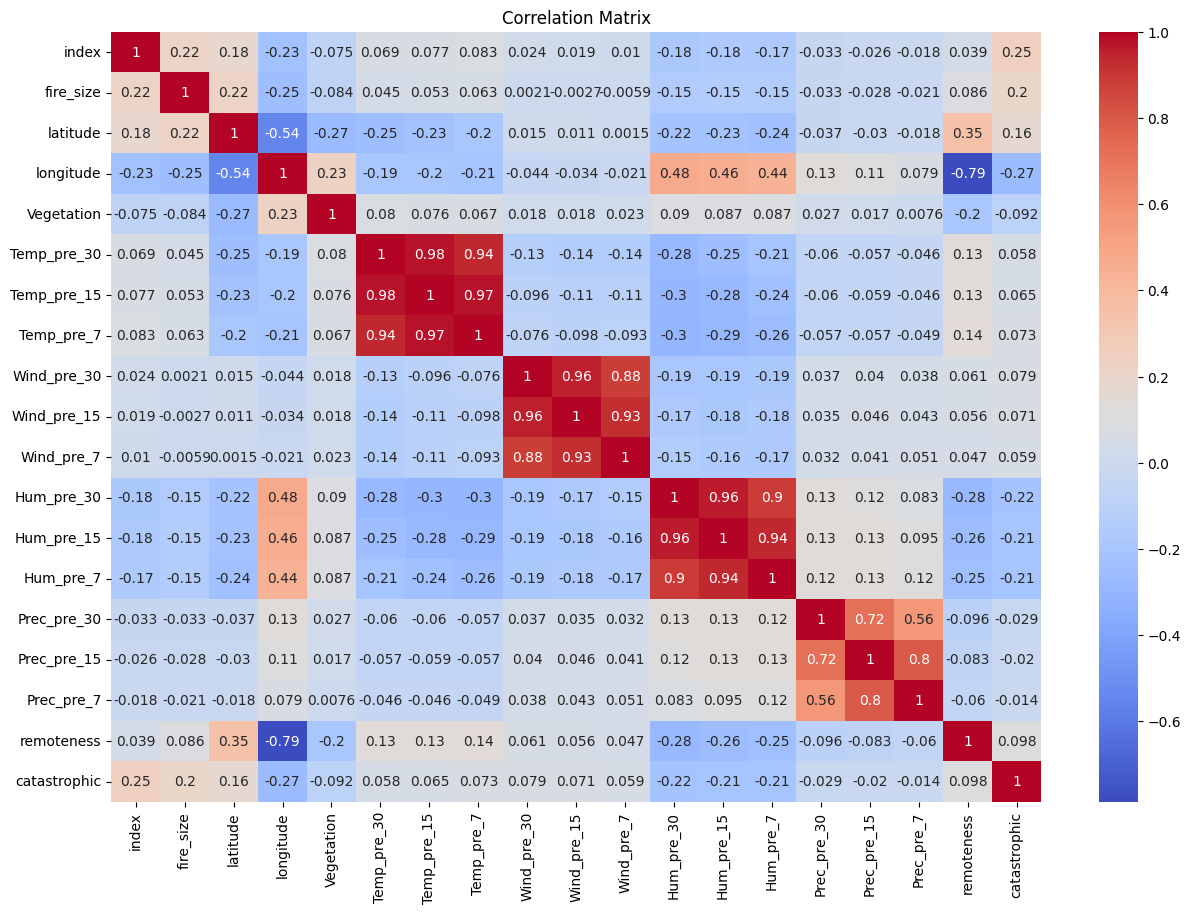

In [59]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

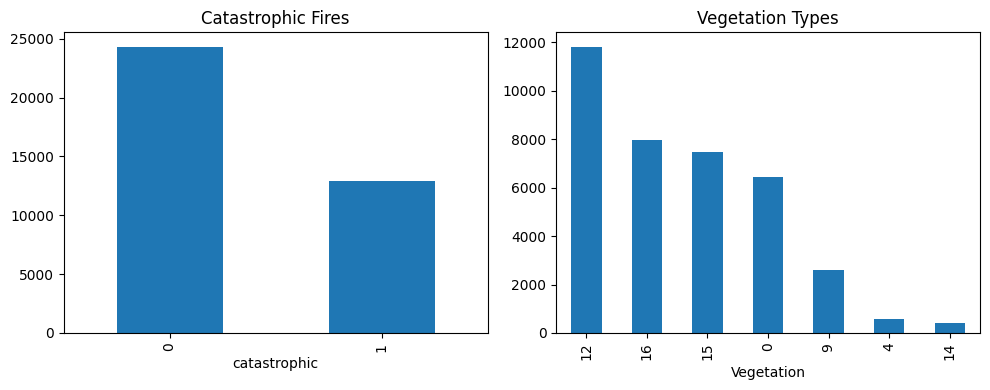

In [60]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  

# Plot the first bar chart
df["catastrophic"].value_counts().plot(kind="bar", ax=axes[0], title="Catastrophic Fires")

# Plot the second bar chart
df["Vegetation"].value_counts().plot(kind="bar", ax=axes[1], title="Vegetation Types")

# Improve layout
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

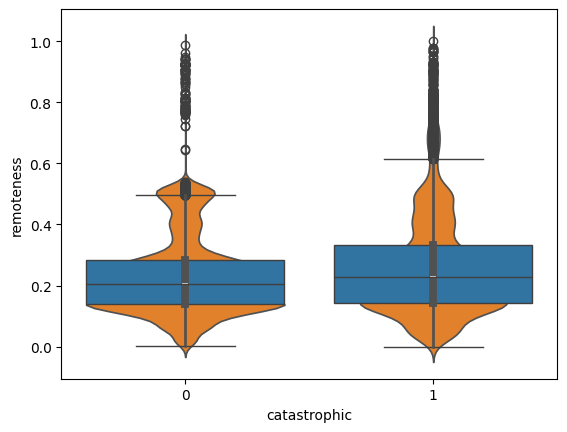

<Figure size 1000x600 with 0 Axes>

In [61]:
sns.boxplot(x='catastrophic', y='remoteness', data=df)
sns.violinplot(x='catastrophic', y='remoteness', data=df)
plt.figure(figsize=(10, 6))

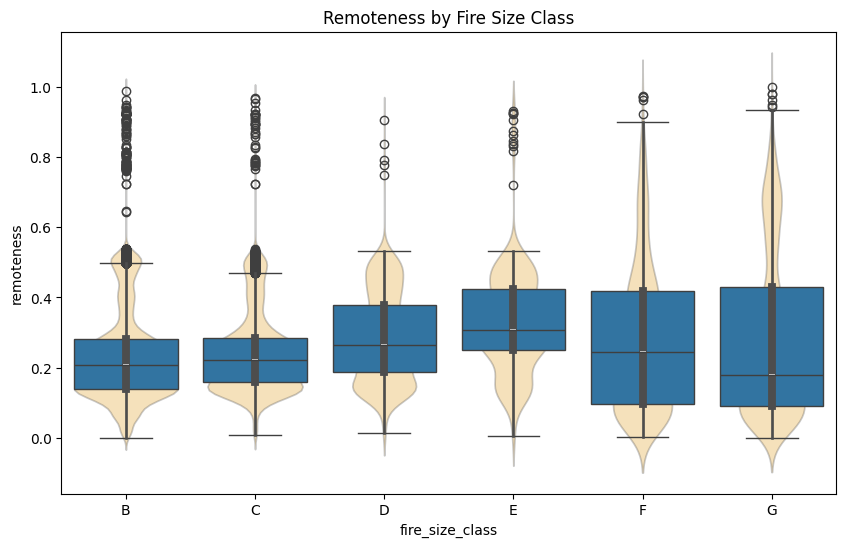

In [62]:
# Define the desired order explicitly
size_order = ['B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(10, 6))
sns.boxplot(x='fire_size_class', y='remoteness', data=df, order=size_order)
sns.violinplot(x='fire_size_class', y='remoteness', data=df, order=size_order, color='orange', alpha=0.3)

plt.title("Remoteness by Fire Size Class")
plt.show()

<Axes: xlabel='fire_size_class', ylabel='count'>

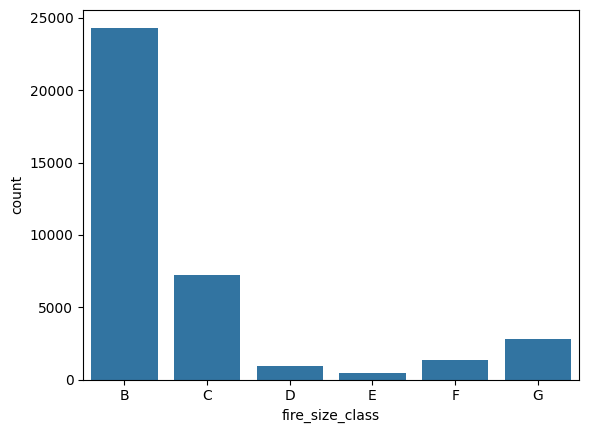

In [63]:
sns.countplot(x='fire_size_class', data=df, order=['B', 'C', 'D', 'E', 'F', 'G'])



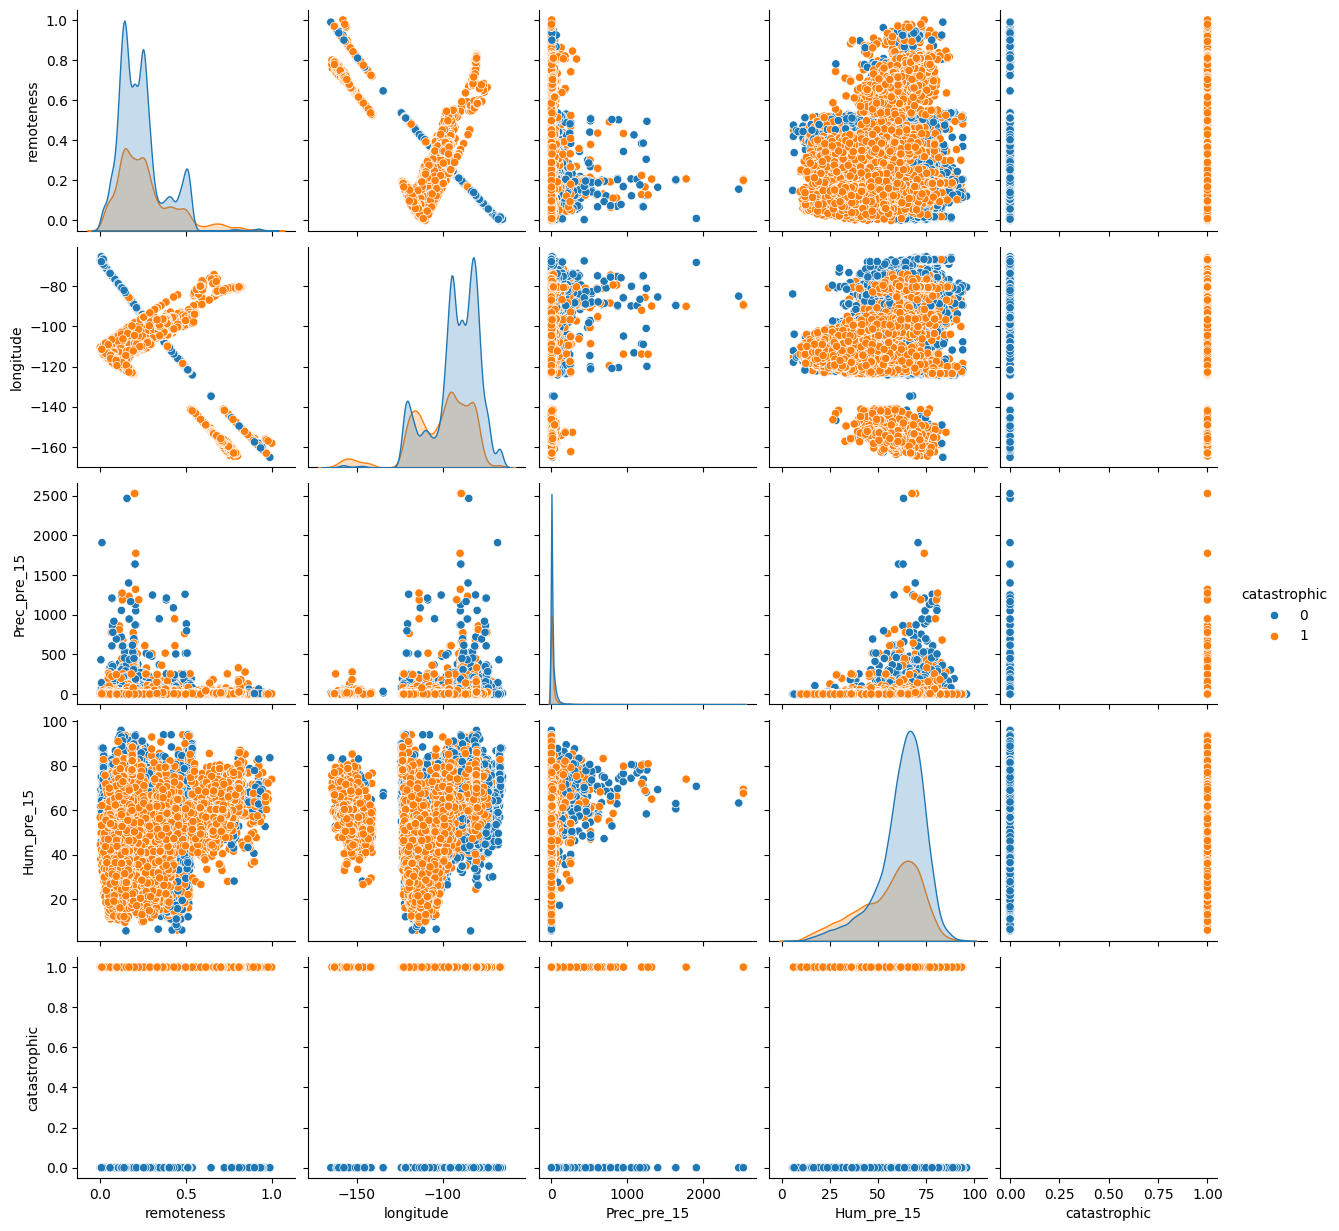

In [64]:
sns.pairplot(df, vars=['remoteness', 'longitude', 'Prec_pre_15','Hum_pre_15', 'catastrophic'], hue='catastrophic')


In [70]:
df_transformed = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv')

df_transformed["fire_size"] = df["fire_size"]

In [71]:
df_transformed = df_transformed.drop(['index'], axis=1)
df_transformed.head()
df_transformed.info()
df_transformed.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37208 entries, 0 to 37207
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       37208 non-null  float64
 1   longitude      37208 non-null  float64
 2   Temp_pre_30    37208 non-null  float64
 3   Temp_pre_15    37208 non-null  float64
 4   Temp_pre_7     37208 non-null  float64
 5   Wind_pre_30    37208 non-null  float64
 6   Wind_pre_15    37208 non-null  float64
 7   Wind_pre_7     37208 non-null  float64
 8   Hum_pre_30     37208 non-null  float64
 9   Hum_pre_15     37208 non-null  float64
 10  Hum_pre_7      37208 non-null  float64
 11  Prec_pre_30    37208 non-null  float64
 12  Prec_pre_15    37208 non-null  float64
 13  Prec_pre_7     37208 non-null  float64
 14  remoteness     37208 non-null  float64
 15  catastrophic   37208 non-null  int64  
 16  month_sin      37208 non-null  float64
 17  month_cos      37208 non-null  float64
 18  Vegeta

,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic,month_sin,month_cos,fire_size
count,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,3.720800e+04,37208.000000,37208.000000
mean,36.475461,-95.643236,15.751560,16.252676,16.611517,3.171764,3.160079,3.136735,60.973810,60.040488,58.948962,39.482359,17.723995,7.361304,0.243298,0.346216,1.206883e-01,-0.172705,2211.284929
std,6.813169,15.877186,8.534825,8.417871,8.474401,1.177843,1.227829,1.313413,13.714828,14.182339,14.894387,134.725873,68.620599,37.778079,0.144646,0.475769,7.412336e-01,0.637343,14890.174705
min,17.958364,-165.116700,-16.078723,-37.000000,-48.200000,0.024922,0.017250,0.000000,5.625000,5.625000,5.625000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000,0.510000
25%,32.377439,-103.445108,9.127583,9.715080,10.037742,2.350902,2.299691,2.221819,55.237437,53.461904,50.968015,0.000000,0.000000,0.000000,0.140661,0.000000,-5.000000e-01,-0.866025,1.100000
50%,34.699420,-93.185815,15.555082,16.070776,16.600000,3.072371,3.053857,3.010513,64.213802,63.044628,61.650099,3.400000,0.000000,0.000000,0.210863,0.000000,1.224647e-16,-0.500000,4.000000
75%,39.783547,-83.550410,23.115392,23.434649,23.793842,3.868383,3.877827,3.891667,70.334410,69.892706,69.469600,43.600000,15.125000,2.300000,0.291913,1.000000,8.660254e-01,0.500000,20.000000
max,69.047200,-65.417709,41.677820,51.567797,55.000000,29.800000,29.800000,29.800000,96.000000,96.000000,100.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000,1.000000e+00,1.000000,538049.000000


In [90]:
df_transformed['month_angle'] = np.arctan2(df_transformed['month_sin'], df_transformed['month_cos'])
df_transformed['month_angle'] = (df_transformed['month_angle'] + 2 * np.pi) % (2 * np.pi)


# Assign bin labels for visualization
df_transformed['month_bin'] = pd.cut(df_transformed['month_angle'], bins=12, labels=False)

# Group by month_bin to get count or mean fire size
month_stats = df_transformed.groupby('month_bin').agg(
    fire_count=('fire_size', 'count'),
    fire_median=('fire_size', 'median')
).reset_index()

# Convert bins back to center angles for plotting
month_stats['angle'] = (month_stats['month_bin'] + 0.5) * (2 * np.pi / 12)



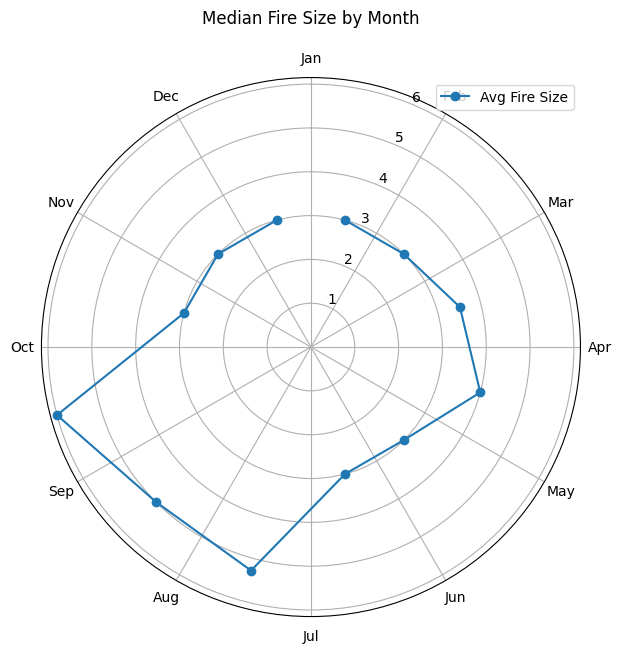

In [92]:
plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Line or bar plot (choose one)
ax.plot(month_stats['angle'], month_stats['fire_median'], marker='o', label="Avg Fire Size")
# ax.bar(month_stats['angle'], month_stats['fire_mean'], width=0.5, alpha=0.6)

# Format
ax.set_theta_direction(-1)       # Clockwise
ax.set_theta_offset(np.pi / 2)   # Start at top
ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.set_title("Median Fire Size by Month", pad=20)
plt.legend()
plt.show()


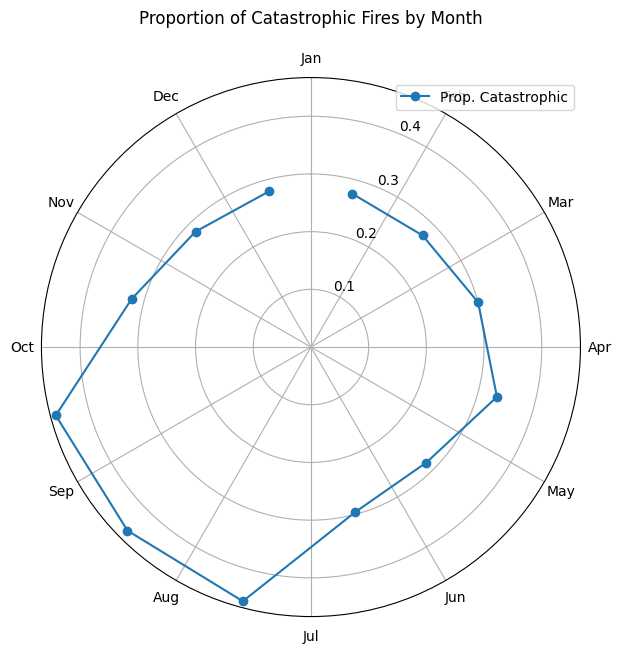

In [80]:
# Group by month_bin to get count or mean fire size
month_stats_c = df_transformed.groupby('month_bin').agg(
    catastrophic_count=('catastrophic', 'count'),
    catastrophic_mean=('catastrophic', 'mean')
).reset_index()

# Convert bins back to center angles for plotting
month_stats_c['angle'] = (month_stats_c['month_bin'] + 0.5) * (2 * np.pi / 12)

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Line or bar plot (choose one)
ax.plot(month_stats_c['angle'], month_stats_c['catastrophic_mean'], marker='o', label="Prop. Catastrophic")
# ax.bar(month_stats['angle'], month_stats['fire_mean'], width=0.5, alpha=0.6)

# Format
ax.set_theta_direction(-1)       # Clockwise
ax.set_theta_offset(np.pi / 2)   # Start at top
ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.set_title("Proportion of Catastrophic Fires by Month", pad=20)
plt.legend()
plt.show()

0     0.275338
1     0.273567
2     0.299877
3     0.333708
4     0.282954
5     0.296179
6     0.456051
7     0.449742
8     0.457853
9     0.321754
10    0.282901
11    0.279517
Name: catastrophic_mean, dtype: float64

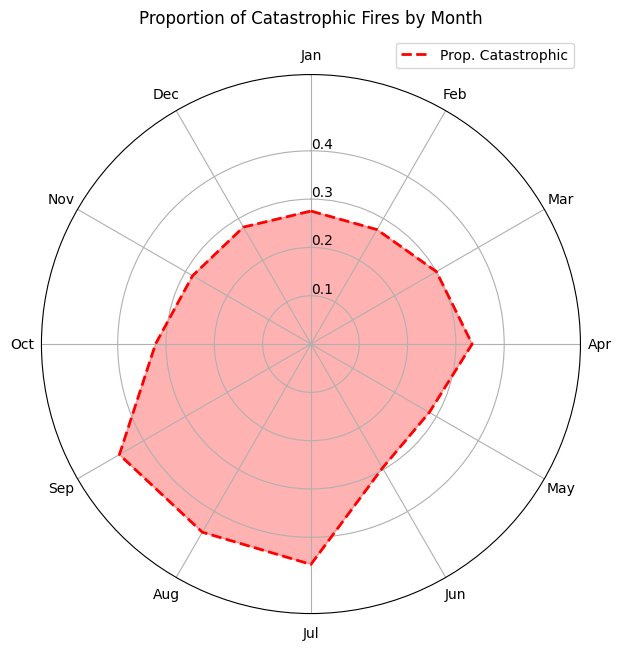

In [89]:
import matplotlib.pyplot as plt

# 12 monthly values (0 to 1) for proportion of catastrophic fires
categories = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
values = list(month_stats_c['catastrophic_mean'].head(12))  

# Data
labels = np.array(categories)
stats = np.array(values)

# Repeat first value to close the circular graph
stats = np.concatenate((stats, [stats[0]]))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Setup figure
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Draw the outline
ax.plot(angles, stats, linewidth=2, linestyle='dashed', color = 'red' ,  label='Prop. Catastrophic')
ax.fill(angles, stats, alpha=0.3, color = 'red')

# Fix axis
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Set labels
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# Optional: adjust y-ticks
ax.set_rlabel_position(0)
ax.set_ylim(0, max(stats) + 0.1)
ax.set_yticks([0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels(["0.1", "0.2", "0.3", "0.4"])

# Title + legend
plt.title("Proportion of Catastrophic Fires by Month", y=1.08)
plt.legend(loc='lower right', bbox_to_anchor=(1, 1))
plt.show()


